In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

import utils_data
import utils_plot

inf >> read data shape is torch.Size([17420, 1])


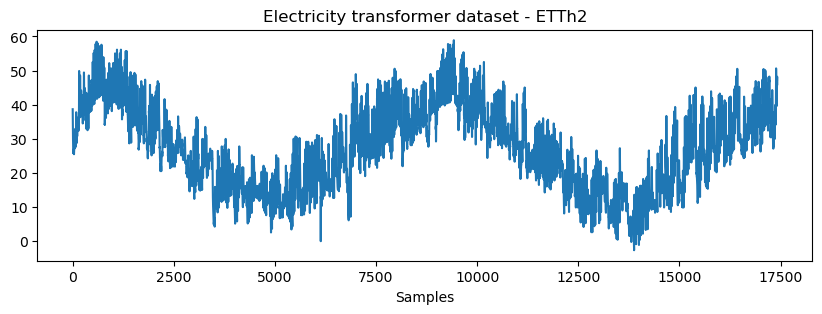

In [2]:
# --! data readout from a file --!

def convert(s):
    """Converts a string ``s`` to a float."""
    return float(s)

def read_detuning(name: str, jcol_read: list[int], nrow_skip: int=0, delim: str=None):
    return torch.tensor(
        np.loadtxt(
            name,
            delimiter=delim,
            skiprows=nrow_skip,
            usecols=jcol_read,
            dtype=np.float32,
            ndmin=2,
            converters=convert))

dataname = '../../data/baselines/ETTh2.csv'
rawdata  = read_detuning(dataname, jcol_read=[7], nrow_skip=1, delim=',')

print(f'inf >> read data shape is {rawdata.shape}')

plt.figure(figsize=(10, 3))
plt.title('Electricity transformer dataset - ETTh2')
plt.plot(rawdata[:, 0])
plt.xlabel('Samples')
plt.show()

/Users/maalberg/Documents/postdoc/dev/care_py/utils_data.py:51: RuntimeWarning: invalid value encountered in divide
  power_spectrum /= np.sum(power_spectrum)  # normalize to get a probability distribution


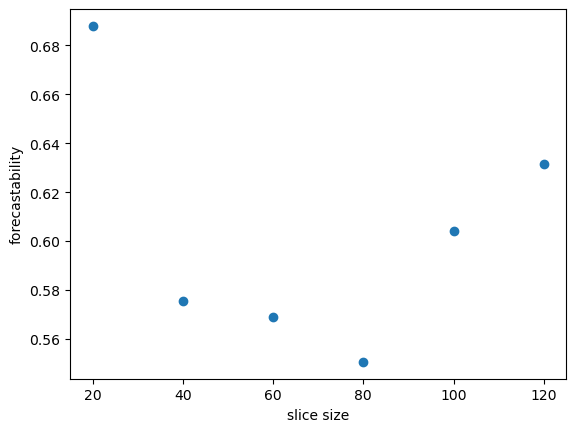

In [3]:
slice_nsample = [20, 40, 60, 80, 100, 120]

fore = []

for nsample in slice_nsample:
    data = torch.split(rawdata[:, 0], nsample)
    fore.append(np.mean([utils_data.forecastability(d) for d in data]))

plt.figure()
plt.scatter(slice_nsample, fore)
plt.xlabel('slice size')
plt.ylabel('forecastability')
plt.show()

datasaved = True

if datasaved:
    x        = torch.tensor(slice_nsample).reshape(-1, 1)
    y        = torch.tensor(fore).reshape(-1, 1)
    savedir  = '../../savedata/baselines/et'
    filename = 'forecastability'
    savedata = torch.cat([x, y], dim=1)
    savedata = torch.unsqueeze(savedata, 0)
    utils_data.write_datafile(f'{savedir}/{filename}', savedata, delim=' ')

In [ ]:
train_io, test_io = train_test_split(rawdata, shuffle=False)

train_nsample = train_io.shape[0]
test_nsample  = test_io.shape[0]

print(f'inf >> number of training and test samples is {train_nsample} and {test_nsample}, respectively')

plt.figure(figsize=(0.75 * 10, 3))
plt.title('Training data')
plt.plot(train_io)
plt.show()

plt.figure(figsize=(0.75 * 10, 3))
plt.title('Training data zoomed')
plt.plot(train_io[2000:2120])
plt.show()

In [ ]:
# --! load a trained stationary model --!

model = torch.load('../../models/baselines/et_kind_filter.pt', weights_only=False)
model.eval()

In [ ]:
datasaved = True

if datasaved:
    datum            = train_io
    savedir          = '../../data/baselines/et_train_stat'
    utils_data.save_stat(model, savedir, [datum])

In [ ]:
datasaved = True

if datasaved:
    datum            = train_io
    savedir          = '../../data/baselines/et_train_trans'
    utils_data.save_trans(model, savedir, [datum])

In [ ]:
datasaved = True

if datasaved:
    timeseries_nsample = model.lookback_nsample + model.forecast_nsample

    savedir_stat  = '../../data/baselines/et_train_stat'
    savedir_trans = '../../data/baselines/et_train_trans'
    savedir_mixed = '../../data/baselines/et_train_mixed'

    utils_data.save_mixed_dataset(savedir_stat, savedir_trans, timeseries_nsample, savedir_mixed)

In [ ]:
datasaved = True

if datasaved:
    savedir  = '../../data/baselines/et_test'
    filename = 'eval'
    testdata = test_io
    testdata = torch.unsqueeze(testdata, 0)
    utils_data.write_datafile(f'{savedir}/{filename}', testdata)